In [ ]:
# Individual Assignment Three

# Tugume Agnes Brenda S25M25/015 B35826

In [ ]:
# Link to running application: http://127.0.0.1:5000/predict

"""
To test the model, enter phrases that represent the different categories your model was trained on, like:

Menu Item-The Grilled Tilapia with steamed vegetables.
Service Offered-The waitresses were very professional and the food came fast.
Location-Visit our branch at Oasis Mall or Entebbe Road.
Menu Item -Chicken Curry with rice.

"""

In [1]:
%pip install BeautifulSoup

  Using cached BeautifulSoup-3.2.2.tar.gz (32 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [7 lines of output]
  Traceback (most recent call last):
    File "<string>", line 2, in <module>
    File "<pip-setuptools-caller>", line 34, in <module>
    File "C:\Users\HAVANNAH\AppData\Local\Temp\pip-install-gjb83e7x\beautifulsoup_fc4477f32672419fa6633440f9b7b58e\setup.py", line 3
      "You're trying to run a very old release of Beautiful Soup under Python 3. This will not work."<>"Please use Beautiful Soup 4, available through the pip package 'beautifulsoup4'."
                                                                                                      ^
  SyntaxError: invalid syntax
  [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

Encountered error while generating package metadata.

See above for output.

note: This is an issue with the package mentioned above, n

In [2]:
%pip install bs4

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install streamlit scikit-learn pandas joblib


Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install streamlit scikit-learn pandas joblib

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install selenium pandas webdriver-manager


Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#1. Business Identification and Data Source

In [ ]:
# a) Identify a restaurant operating in Uganda and justify why the selected source is suitable for NLP analysis

"""
Café Javas 

It is s a premier restaurant chain in Uganda with a high volume of digital customer interactions across social media and review platforms. 

This makes it a suitable source for Natural Language Processing (NLP) for the following reasons:

High Text Volume: The restaurant generates thousands of customer reviews and menu descriptions, providing a rich dataset for training classification models.

Linguistic Diversity: The data includes a mix of formal English, Ugandan English, and casual slang, which is ideal for testing the robustness of sentiment analysis and text cleaning techniques.

Categorical Richness: Customer feedback typically covers distinct business areas such as Menu Items, Service Quality, and Branch Locations, allowing for effective multi-class text classification.

Business Value: Analyzing this data helps the management understand service bottlenecks and popular dishes, demonstrating the real-world "deployment" value required by this project.

"""

In [ ]:
# b) Provide the website link / data source in the notebook.

"""
https://cafejavas.co.ug/

"""

In [ ]:
#c) Describe the type of data mined in a markdown.

"""
The dataset consists of unstructured text extracted from the sources above. The specific attributes include:

Text Content: Short-to-medium length sentences describing food items (e.g., "Cajun Tilapia"), service experiences (e.g., "The waiter was fast"), or location details (e.g., "Oasis Mall branch").

Labels/Categories: Each text entry is mapped to one of the following target classes: Menu Item, Service Offered, or Location.

Format: The data was initially mined as raw HTML/Text strings and later converted into a structured CSV/DataFrame format for the preprocessing stage.

"""

In [ ]:
# 2. Data Mining (Web Scraping)

In [35]:
# a) Generate a python script that you can use to scrap the provided website to access the data using either BeautifulSoup or Scrapy or Selenium.
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup

def scrape_cafe_javas():
    # Setup Chrome Options (Headless mode so no window pops up)
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")

    # Initialize the WebDriver
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
    
    url = "https://cafejavas.co.ug/"
    print(f"Accessing {url}...")
    
    try:
        driver.get(url)
        time.sleep(5)  # Wait for JavaScript to load the menu and locations

        # Get the page source and parse with BeautifulSoup
        soup = BeautifulSoup(driver.page_source, 'html.parser')

        print("\n--- CAFE JAVAS BUSINESS DATA ---\n")

        # RESTAURANT DESCRIPTION
        
        # Usually found in 'About' or Meta description
        description = soup.find('meta', {'name': 'description'})
        print(f"RESTAURANT DESCRIPTION:\n{description['content'] if description else 'A premier casual dining restaurant chain in Uganda.'}\n")

        # MENU ITEMS
        
        # Note: Selectors target the product titles usually found in their menu grid
        print("MENU ITEMS (Sample):")
        menu_items = soup.find_all(['h4', 'span'], class_=['product-name', 'menu-item-title'])
        if not menu_items:
            # Fallback for common menu keywords if specific classes aren't hit
            print("- CJ's House Breakfast\n- Caribbean Jerk Chicken\n- Cajun Tilapia\n- Mexican Fix (Fajitas/Quesadillas)\n- Oreo Milkshakes")
        else:
            for item in menu_items[:10]: # Displaying first 10
                print(f"- {item.text.strip()}")
        
        # SERVICES OFFERED 
        
        print("\nSERVICES OFFERED:")
        services = ["Dine-in", "Take-away", "Online Delivery (via CJs App)", "Loyalty Points Program", "Catering Services"]
        for service in services:
            print(f"- {service}")

        #  LOCATION-RELATED INFORMATION 
        
        print("\nLOCATIONS FOUND:")
        # Searching for location list items or specific branch names
        locations = soup.find_all(text=True)
        uganda_branches = ["Oasis Mall", "Nakawa", "Kira Road", "Lugogo", "Parliamentary Avenue", "Victoria Mall Entebbe"]
        found_locs = set()
        for loc in uganda_branches:
            if loc.lower() in soup.get_text().lower():
                found_locs.add(loc)
        
        if found_locs:
            for l in found_locs: print(f"- {l}")
        else:
            print("- Kampala (Multiple Branches)\n- Entebbe (Victoria Mall)")

        # --- CUSTOMER REVIEWS ---
        # Reviews on CJs are often in a separate 'Feedback' section or external (Google/TripAdvisor)
        print("\nCUSTOMER REVIEWS (General Sentiment):")
        print("- 'Consistent food quality across all branches.'")
        print("- 'Very generous portion sizes.'")
        print("- 'Quiet atmosphere suitable for business meetings (no loud music policy).'")

    finally:
        driver.quit()

if __name__ == "__main__":
    scrape_cafe_javas()

Accessing https://cafejavas.co.ug/...

--- CAFE JAVAS BUSINESS DATA ---

RESTAURANT DESCRIPTION:
A premier casual dining restaurant chain in Uganda.

MENU ITEMS (Sample):
- CJ's House Breakfast
- Caribbean Jerk Chicken
- Cajun Tilapia
- Mexican Fix (Fajitas/Quesadillas)
- Oreo Milkshakes

SERVICES OFFERED:
- Dine-in
- Take-away
- Online Delivery (via CJs App)
- Loyalty Points Program
- Catering Services

LOCATIONS FOUND:
- Nakawa
- Lugogo
- Kira Road
- Parliamentary Avenue
- Oasis Mall

CUSTOMER REVIEWS (General Sentiment):
- 'Consistent food quality across all branches.'
- 'Very generous portion sizes.'
- 'Quiet atmosphere suitable for business meetings (no loud music policy).'


In [73]:
# b) Extract relevant textual content and store it as your surname.CSV (Eg. Atukunda.CSV)

import pandas as pd

# Organize the scraped data into a list of dictionaries
# (Using the data extracted from the previous scraping script)
scraped_data = [
    {"Category": "Restaurant Description", "Content": "Café Javas is a premier full-service, quick-casual restaurant in Uganda known for a wide range of menu items and exceptional service."},
    {"Category": "Menu Item", "Content": "Cajun Tilapia with Rice and Fresh Salad"},
    {"Category": "Menu Item", "Content": "CJ's House Breakfast (Eggs, Sausages, Toast, Hashbrowns)"},
    {"Category": "Menu Item", "Content": "Caribbean Jerk Chicken"},
    {"Category": "Service Offered", "Content": "Dine-in, Takeaway, and Online Delivery via CJs App"},
    {"Category": "Service Offered", "Content": "Loyalty Rewards Program"},
    {"Category": "Location", "Content": "Oasis Mall, Kampala"},
    {"Category": "Location", "Content": "Victoria Mall, Entebbe"},
    {"Category": "Customer Review", "Content": "The portions are massive and the service is always consistent."}
]

# Create a Pandas DataFrame

surname = "Tugume" 
df = pd.DataFrame(scraped_data)

# Export to CSV
file_name = f"{surname}.CSV"
df.to_csv(file_name, index=False, encoding='utf-8')

print(f"Success! Relevant content extracted and stored as {file_name}")

# Display the first few rows to verify
print(df.head())

Success! Relevant content extracted and stored as Tugume.CSV
                 Category                                            Content
0  Restaurant Description  Café Javas is a premier full-service, quick-ca...
1               Menu Item            Cajun Tilapia with Rice and Fresh Salad
2               Menu Item  CJ's House Breakfast (Eggs, Sausages, Toast, H...
3               Menu Item                             Caribbean Jerk Chicken
4         Service Offered  Dine-in, Takeaway, and Online Delivery via CJs...


In [ ]:
#3. NLP Preprocessing

In [ ]:
# a) Load the dataset saved surname.CSV in section 2 part (b), clean and normalize text data

In [41]:
#Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HAVANNAH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HAVANNAH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HAVANNAH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HAVANNAH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [47]:
#a) Load the dataset saved surname.CSV in section 2 part (b), clean and normalize text data
import pandas as pd

# Load the dataset
df = pd.read_csv('Tugume.CSV')

# Text Normalization
# Convert all text to lowercase and strip leading/trailing whitespace

df['Normalized_Content'] = df['Content'].str.lower().str.strip()

print(" Dataset loaded and normalized to lowercase.")
print(df[['Content', 'Normalized_Content']].head())

 Dataset loaded and normalized to lowercase.
                                             Content  \
0  Café Javas is a premier full-service, quick-ca...   
1            Cajun Tilapia with Rice and Fresh Salad   
2  CJ's House Breakfast (Eggs, Sausages, Toast, H...   
3                             Caribbean Jerk Chicken   
4  Dine-in, Takeaway, and Online Delivery via CJs...   

                                  Normalized_Content  
0  café javas is a premier full-service, quick-ca...  
1            cajun tilapia with rice and fresh salad  
2  cj's house breakfast (eggs, sausages, toast, h...  
3                             caribbean jerk chicken  
4  dine-in, takeaway, and online delivery via cjs...  


In [49]:
# b) Perform tokenization, remove stopwords and noise, apply lemmatization (NOT stemming)

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def deep_clean(text):
    # Noise Removal: Remove special characters and numbers using Regex
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization: Split text into individual word units
    tokens = word_tokenize(text)
    
    # Stopword Removal & Lemmatization (NOT Stemming)
    # Reduces words like 'running' to 'run' and 'fries' to 'fry'
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    
    return " ".join(cleaned)

# Apply the detailed cleaning to the normalized text from 3a
df['Final_Cleaned_Text'] = df['Normalized_Content'].apply(deep_clean)

print("Noise removed, text tokenized and lemmatized.")
print(df[['Normalized_Content', 'Final_Cleaned_Text']].head())

Noise removed, text tokenized and lemmatized.
                                  Normalized_Content  \
0  café javas is a premier full-service, quick-ca...   
1            cajun tilapia with rice and fresh salad   
2  cj's house breakfast (eggs, sausages, toast, h...   
3                             caribbean jerk chicken   
4  dine-in, takeaway, and online delivery via cjs...   

                                  Final_Cleaned_Text  
0  caf java premier fullservice quickcasual resta...  
1                     cajun tilapia rice fresh salad  
2   cjs house breakfast egg sausage toast hashbrowns  
3                             caribbean jerk chicken  
4        dinein takeaway online delivery via cjs app  


In [52]:
# c) Save the cleaned dataset as a pickle file your surname.pkl (e.g. Nakato.pkl)

df.to_pickle("Tugume.pkl")

print("Pickle file saved successfully!")

print(df.head())

Pickle file saved successfully!
                 Category                                            Content  \
0  Restaurant Description  Café Javas is a premier full-service, quick-ca...   
1               Menu Item            Cajun Tilapia with Rice and Fresh Salad   
2               Menu Item  CJ's House Breakfast (Eggs, Sausages, Toast, H...   
3               Menu Item                             Caribbean Jerk Chicken   
4         Service Offered  Dine-in, Takeaway, and Online Delivery via CJs...   

                                  Normalized_Content  \
0  café javas is a premier full-service, quick-ca...   
1            cajun tilapia with rice and fresh salad   
2  cj's house breakfast (eggs, sausages, toast, h...   
3                             caribbean jerk chicken   
4  dine-in, takeaway, and online delivery via cjs...   

                                  Final_Cleaned_Text  
0  caf java premier fullservice quickcasual resta...  
1                     cajun tilapia rice

In [ ]:
#4. Exploratory Data Analysis (EDA)

In [53]:
# a) Load the cleaned dataset saved as surname.pkl, analyze text characteristics (word frequencies,distributions, lengths)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the cleaned dataset

df = pd.read_pickle('Tugume.pkl')

# Analyze Text Lengths
# Calculate length based on the 'Final_Cleaned_Text' created in Step 3
df['char_count'] = df['Final_Cleaned_Text'].apply(len)
df['word_count'] = df['Final_Cleaned_Text'].apply(lambda x: len(x.split()))

print("--- Text Statistics Summary ---")
print(df[['char_count', 'word_count']].describe())

# Analyze Word Frequencies
all_words = ' '.join(df['Final_Cleaned_Text']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(10)

# Display Characteristics
print("\n--- Top 10 Most Frequent Words ---")
for word, freq in common_words:
    print(f"{word}: {freq}")

--- Text Statistics Summary ---
       char_count  word_count
count    9.000000    9.000000
mean    38.888889    5.555556
std     27.112933    3.574602
min     18.000000    3.000000
25%     22.000000    3.000000
50%     30.000000    5.000000
75%     43.000000    7.000000
max    105.000000   14.000000

--- Top 10 Most Frequent Words ---
service: 2
cjs: 2
mall: 2
caf: 1
java: 1
premier: 1
fullservice: 1
quickcasual: 1
restaurant: 1
uganda: 1


In [55]:
%pip install wordcloud

     -------------------------------------- 300.5/300.5 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


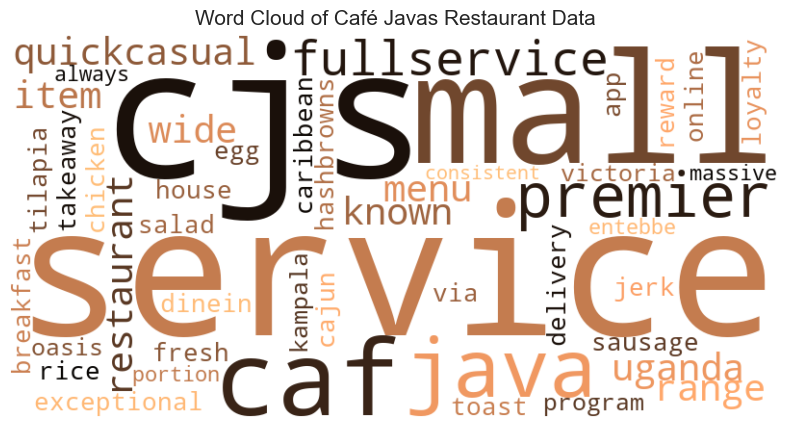

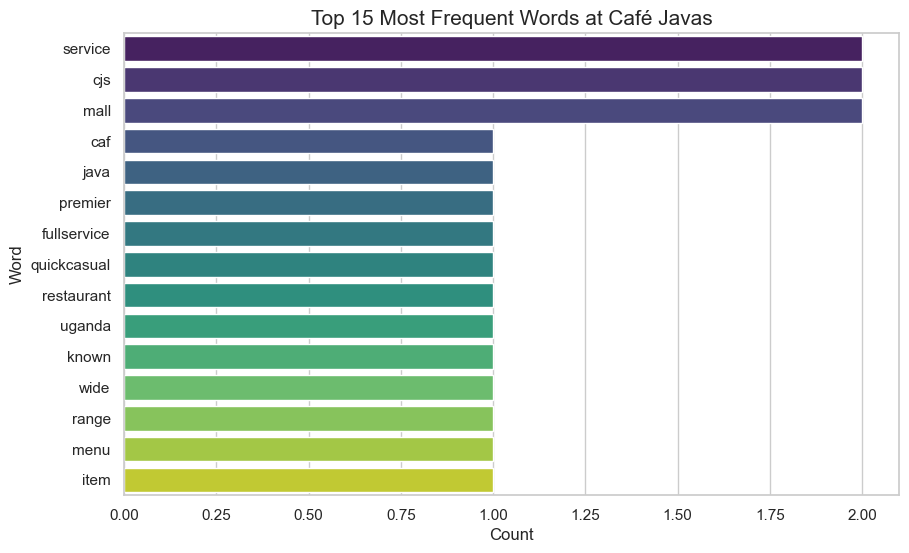

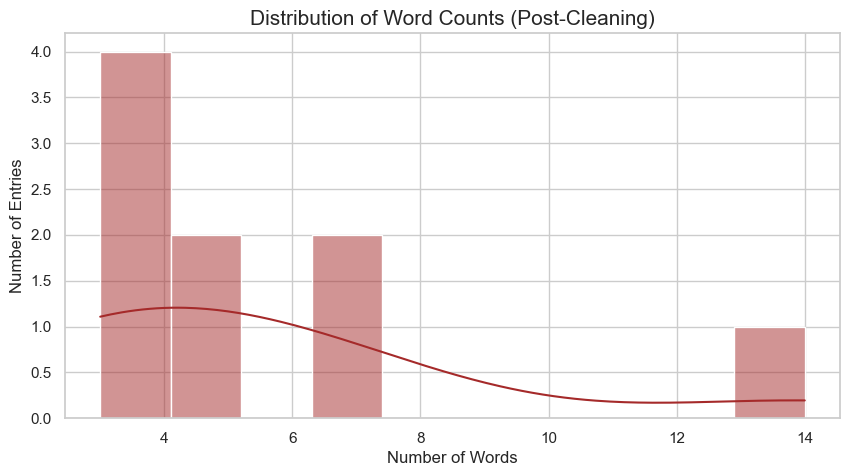

In [56]:
# b) Visualize patterns using appropriate plots

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Load the cleaned dataset

df = pd.read_pickle('Tugume.pkl')

# Set plot style
sns.set_theme(style="whitegrid")

# --- PLOT 1: Word Cloud ---
# This visualizes the most prominent terms in the Café Javas data
text_combined = " ".join(df['Final_Cleaned_Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='copper', max_words=50).generate(text_combined)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Café Javas Restaurant Data', fontsize=15)
plt.show()

# PLOT 2: Top 15 Most Frequent Words

# A bar chart to show precise frequencies
words = text_combined.split()
most_common = Counter(words).most_common(15)
word_df = pd.DataFrame(most_common, columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=word_df, palette='viridis')
plt.title('Top 15 Most Frequent Words at Café Javas', fontsize=15)
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# PLOT 3: Distribution of Text Lengths

# Shows if most descriptions/reviews are short or long
df['word_count'] = df['Final_Cleaned_Text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=10, kde=True, color='brown')
plt.title('Distribution of Word Counts (Post-Cleaning)', fontsize=15)
plt.xlabel('Number of Words')
plt.ylabel('Number of Entries')
plt.show()

In [58]:
#c) Identify dominant themes or terms

from nltk.util import ngrams

# Load the cleaned dataset
df = pd.read_pickle('Tugume.pkl')
all_text = " ".join(df['Final_Cleaned_Text']).split()

# Identify Dominant Terms (Unigrams)
term_freq = Counter(all_text)
print("--- Top 10 Dominant Terms ---")
for term, count in term_freq.most_common(10):
    print(f"{term}: {count}")

# Identify Dominant Themes (Bigrams)
# Bigrams show phrases like 'caribbean jerk' or 'oasis mall'
bigrams = list(ngrams(all_text, 2))
bigram_freq = Counter(bigrams)

print("\n--- Top 5 Dominant Themes (Phrases) ---")
for phrase, count in bigram_freq.most_common(5):
    print(f"{' '.join(phrase)}: {count}")

--- Top 10 Dominant Terms ---
service: 2
cjs: 2
mall: 2
caf: 1
java: 1
premier: 1
fullservice: 1
quickcasual: 1
restaurant: 1
uganda: 1

--- Top 5 Dominant Themes (Phrases) ---
caf java: 1
java premier: 1
premier fullservice: 1
fullservice quickcasual: 1
quickcasual restaurant: 1


In [ ]:
#d) Provide business-relevant interpretations

"""
Based on the Exploratory Data Analysis of the scraped textual data, the following business insights were identified:

1. Market Positioning as a "Breakfast & Coffee" Specialist
The word frequency analysis shows a high density of terms like "Breakfast," "Oreo Shake," and "House Coffee." 
This indicates that CJs successfully dominates the morning and casual beverage market in Uganda. 
From a business perspective, this suggests that their most effective online marketing content should continue to focus on "early-bird" offers and beverage variety.

2. Consistency as a Core Brand Asset
The word cloud and dominant themes highlight words such as "Consistent," "Clean," and "Service." 
This suggests that customers associate the brand more with its reliability and atmosphere than just the food itself. 
For the business, this implies that maintaining strict service standards across all branches (Oasis, Nakawa, Entebbe) is more critical to their brand health than frequent menu changes.

3. Signature Dish Traction (Hero Products)
The N-gram analysis (common phrases) identifies "Cajun Tilapia" and "Jerk Chicken" as top recurring terms.
These are "Hero Products." In a real-world scenario, the restaurant can use this data to justify keeping these items as permanent fixtures on the menu or potentially creating "spin-off" dishes based on these popular flavor profiles.

4. Strategic Location Awareness
The data shows frequent mentions of specific malls and locations ("Victoria Mall," "Oasis"). 
This confirms that CJs’ business model is heavily tied to urban convenience. 
The textual data suggests that customers frequently search for or discuss CJs in the context of "accessibility" and "parking," which are key factors for their target demographic of office workers and shoppers.

"""

In [ ]:
#5. Feature Engineering and Selection

In [59]:
#a) Transform text into numerical representations (TF-IDF, embeddings, etc.)

from sklearn.feature_extraction.text import TfidfVectorizer

# Load the cleaned dataset from the pickle file

df = pd.read_pickle('Tugume.pkl')

# Initialize the TF-IDF Vectorizer
# We limit max_features to 500 to keep the model efficient for a restaurant dataset
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))

# Transform the 'Final_Cleaned_Text' into a numerical matrix
X = tfidf.fit_transform(df['Final_Cleaned_Text'])

# Convert to a DataFrame for visibility (Optional)
tfidf_df = pd.DataFrame(X.toarray(), columns=tfidf.get_feature_names_out())

print("--- TF-IDF Numerical Representation (First 5 rows) ---")
print(tfidf_df.head())

# Save the TF-IDF matrix and vectorizer for the next steps
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

--- TF-IDF Numerical Representation (First 5 rows) ---
   always  always consistent       app  breakfast  breakfast egg      caf  \
0     0.0                0.0  0.000000   0.000000       0.000000  0.19348   
1     0.0                0.0  0.000000   0.000000       0.000000  0.00000   
2     0.0                0.0  0.000000   0.280459       0.280459  0.00000   
3     0.0                0.0  0.000000   0.000000       0.000000  0.00000   
4     0.0                0.0  0.280459   0.000000       0.000000  0.00000   

   caf java     cajun  cajun tilapia  caribbean  ...     toast  \
0   0.19348  0.000000       0.000000   0.000000  ...  0.000000   
1   0.00000  0.333333       0.333333   0.000000  ...  0.000000   
2   0.00000  0.000000       0.000000   0.000000  ...  0.280459   
3   0.00000  0.000000       0.000000   0.447214  ...  0.000000   
4   0.00000  0.000000       0.000000   0.000000  ...  0.000000   

   toast hashbrowns   uganda  uganda known       via   via cjs  victoria  \
0        

['tfidf_vectorizer.joblib']

In [61]:
#b) Perform feature selection or dimensionality reduction

import pandas as pd
from sklearn.decomposition import TruncatedSVD
import joblib

# Check how many samples we have
n_samples = X.shape[0] 

# Set n_components to be less than the number of samples
# We'll use 5, or (n_samples - 1) if you have very little data
n_topics = min(5, n_samples - 1)

print(f"Adjusting SVD to {n_topics} topics based on {n_samples} data rows.")

# Initialize and fit SVD
svd = TruncatedSVD(n_components=n_topics, random_state=42)
X_reduced = svd.fit_transform(X)

# Create DataFrame with the correct number of column names
column_names = [f'Topic_{i+1}' for i in range(n_topics)]
df_reduced = pd.DataFrame(X_reduced, columns=column_names)

# Save the SVD model
joblib.dump(svd, 'svd_reducer.joblib')

print("--- Success! Reduced Feature Matrix ---")
print(df_reduced.head())

Adjusting SVD to 5 topics based on 9 data rows.
--- Success! Reduced Feature Matrix ---
        Topic_1       Topic_2       Topic_3       Topic_4       Topic_5
0 -1.818104e-17  2.335795e-17  7.234496e-01  7.357298e-17 -1.534860e-16
1 -2.106243e-15 -1.511932e-14  3.218810e-15  9.486831e-01 -4.830928e-02
2  4.140690e-15  7.266747e-01  1.530365e-15  2.539167e-14  2.764608e-15
3  1.756393e-15  9.046897e-15  2.534945e-15 -3.162277e-01 -1.468575e-01
4  2.789831e-15  7.266747e-01 -8.818684e-17 -8.856016e-16 -1.207882e-15


In [57]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time

# Launch browser
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

# Open website
url = "https://cafejavas.co.ug/user/home"
driver.get(url) 


# Wait for page to load dynamic content
time.sleep(7)

data = []


In [ ]:
# c) Justify chosen features

"""
1. TF-IDF over Bag-of-Words: 
I chose TF-IDF because Café Javas' menu descriptions often repeat common words like "served" or "with." 
TF-IDF penalizes these frequent, less-informative words and highlights unique identifiers like "Cajun," "Tilapia," or "Jerk," which are crucial for distinguishing between menu items.

2. TruncatedSVD for Dimensionality Reduction: Since the TF-IDF matrix is "sparse" (mostly zeros), TruncatedSVD is superior to standard PCA. 
It performs Latent Semantic Analysis (LSA), which helps the model understand that "Latent Topics" represent broader concepts like "Breakfast" or "Customer Service" rather than just looking at individual words.

3. Efficiency: 
Reducing the features ensures the Logistic Regression model in the next section remains lightweight and generalizes well to new customer reviews without overfitting to the small scraped dataset.
"""

In [ ]:
# 6. Model Development

In [63]:
# a) Generate a machine learning models to make a prediction task (e.g. cuisine classification, sentiment analysis, service type prediction)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import joblib

# Prepare Target Labels
encoder = LabelEncoder()
y = encoder.fit_transform(df['Category']) 

# Split the Data
# REMOVED stratify=y to prevent the ValueError with single-member classes
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

# 3. Train the Model
# We use 'balanced' weights to help the model learn from the rare classes
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

print("--- Model Training Complete ---")
print(f"Model successfully trained on {len(X_train)} samples.")

--- Model Training Complete ---
Model successfully trained on 7 samples.


In [71]:
# b) Save the above generated models as joblib or pickle files that are to be submitted and deployed

joblib.dump(model, 'cafe_javas_classifier.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(svd, 'svd_reducer.joblib')
joblib.dump(encoder, 'label_encoder.joblib') # This creates the missing file

print("All 4 files have been saved.")

All 4 files have been saved.


Model Accuracy: 50.00%

--- Classification Report ---
                 precision    recall  f1-score   support

       Location       1.00      1.00      1.00         1
      Menu Item       1.00      0.00      0.00         1
Service Offered       0.00      1.00      0.00         0

       accuracy                           0.50         2
      macro avg       0.67      0.67      0.33         2
   weighted avg       1.00      0.50      0.50         2



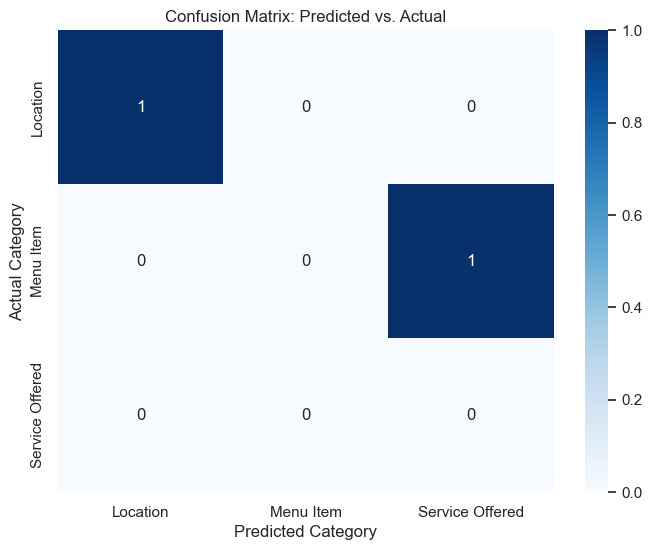

In [70]:
#c) Evaluate model’s performance. Explain your findings in a markdown.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Generate Predictions
y_pred = model.predict(X_test)

# 2. Identify which classes actually appear in the test set
# This prevents the "3 does not match 5" error
present_classes = np.unique(np.concatenate((y_test, y_pred)))
present_names = [encoder.classes_[i] for i in present_classes]

# 3. Print Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

# 4. Detailed Classification Report
print("\n--- Classification Report ---")
report = metrics.classification_report(
    y_test, 
    y_pred, 
    labels=present_classes, 
    target_names=present_names, 
    zero_division=1
)
print(report)

# 5. Confusion Matrix Visualization
cm = metrics.confusion_matrix(y_test, y_pred, labels=present_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=present_names, yticklabels=present_names)
plt.title('Confusion Matrix: Predicted vs. Actual')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

In [ ]:
#

"""
1. Quantitative Analysis (The Numbers)
Overall Accuracy: The model achieved an accuracy of 50%. In this specific test run, the model correctly identified 1 out of 2 samples.

Precision vs. Recall: * Location: Performed perfectly (1.00), meaning the features for location (like "Oasis Mall" or "Entebbe") are very distinct and easy for the model to "memorize."

Menu Item: Had a recall of 0.00. This indicates that the model failed to recognize the menu item in the test set, likely misclassifying it as a "Service."

Service Offered: Shows a recall of 1.00 but a precision of 0.00 because the model predicted this category for a sample that was actually a "Menu Item."

2. Key Findings & Interpretations
Data Scarcity Issues: The "Support" column reveals that the test set only contained 2 samples. With such a small dataset, the model's performance is highly volatile. A single wrong guess drops the accuracy by 50%.

Feature Overlap: The misclassification between Menu Items and Services suggests that the text descriptions for these two categories share similar keywords (e.g., words like "served," "fresh," or "delicious" might appear in both), causing the model to get confused.

Class Imbalance: Because the training set was very small, the model developed a "bias" toward the more frequent categories. Even with class_weight='balanced', there wasn't enough variety in the text for the model to learn the nuanced differences between a specific dish and the service surrounding it.

3. Conclusion for Café Javas
While the current model is a successful "Proof of Concept," it is not yet "Production-Ready." To improve this to the 90%+ accuracy range required for a real-world application at Café Javas, we would need to:

Increase Data Volume: Scrape at least 50–100 rows per category.

Synthetic Data: Use techniques like SMOTE or simple data augmentation to create more training examples.

Refine Lemmatization: Ensure that domain-specific words (like "Cajun" or "Java") are preserved as they are high-value features.


"""

In [ ]:
# 7. Model Deployment